# ParquetDataset Demo

This notebook demonstrates the usage of the `ParquetDataset` class for loading and exploring mass regression data from Parquet files.

In [10]:
# Import Required Libraries
import os
import torch
import numpy as np
import pyarrow.parquet as pq
from torch.utils.data import Dataset
import matplotlib.pyplot as plt

In [11]:
file = pq.ParquetFile('/kaggle/input/datasets/vishalreddyk/brokendataset-testing/top_gun_opendata_0_part_00002.parquet')


In [12]:
row1 = file.read_row_group(0, columns=["X_jet", "m"])

In [14]:
row1

pyarrow.Table
X_jet: list<element: list<element: list<element: double>>>
  child 0, element: list<element: list<element: double>>
      child 0, element: list<element: double>
          child 0, element: double
m: double
----
X_jet: [[[[[0,0,0,0,0,...,0,0,0,0,0],[0,0,0,0,0,...,0,0,0,0,0],...,[0,0,0,0,0,...,0,0,0,0,0],[0,0,0,0,0,...,0,0,0,0,0]],[[0,0,0,0,0,...,0,0,0,0,0],[0,0,0,0,0,...,0,0,0,0,0],...,[0,0,0,0,0,...,0,0,0,0,0],[0,0,0,0,0,...,0,0,0,0,0]],...,[[0,0,0,0,0,...,0,0,0,0,0],[0,0,0,0,0,...,0,0,0,0,0],...,[0,0,0,0,0,...,0,0,0,0,0],[0,0,0,0,0,...,0,0,0,0,0]],[[0,0,0,0,0,...,0,0,0,0,0],[0,0,0,0,0,...,0,0,0,0,0],...,[0,0,0,0,0,...,0,0,0,0,0],[0,0,0,0,0,...,0,0,0,0,0]]],[[[0,0,0,0,0,...,0,0,0,0,0],[0,0,0,0,0,...,0,0,0,0,0],...,[0,0,0,0,0,...,0,0,0,0,0],[0,0,0,0,0,...,0,0,0,0,0]],[[0,0,0,0,0,...,0,0,0,0,0],[0,0,0,0,0,...,0,0,0,0,0],...,[0,0,0,0,0,...,0,0,0,0,0],[0,0,0,0,0,...,0,0,0,0,0]],...,[[0,0,0,0,0,...,0,0,0,0,0],[0,0,0,0,0,...,0,0,0,0,0],...,[0,0,0,0,0,...,0,0,0,0,0],[0,0,0,0,0,

In [9]:
# Helper function for fixed jet array (from dlformr.ipynb)
def _to_fixed_jet_array(x_item, target_channels=4, jet_h=125, jet_w=125):
    """Convert a single X_jet sample to a fixed (C,H,W) float32 array.

    Handles:
      - (H,W) -> adds channel dim
      - (C,H,W) -> crops/pads channels/spatial
      - list/tuple of channels (each (H,W) or flat length H*W)
      - Arrow scalars (via .as_py())

    Never raises on ragged inputs; returns zeros if unparseable.
    """
    if hasattr(x_item, "as_py"):
        x_item = x_item.as_py()

    out = np.zeros((target_channels, jet_h, jet_w), dtype=np.float32)

    # Try direct conversion first (fast when structure is regular).
    x = None
    try:
        x = np.asarray(x_item, dtype=np.float32)
    except (ValueError, TypeError):
        x = None

    if x is not None:
        # If conversion produced an object array, treat as ragged and fall back.
        if x.dtype == object:
            x = None
        else:
            if x.ndim == 2:
                x = x[np.newaxis, ...]
            if x.ndim == 3:
                c = min(x.shape[0], target_channels)
                h = min(x.shape[1], jet_h)
                w = min(x.shape[2], jet_w)
                out[:c, :h, :w] = x[:c, :h, :w]
                return out
            # Some encodings end up as flat vectors; try reshape if plausible.
            if x.ndim == 1 and x.size == jet_h * jet_w:
                out[0, :, :] = x.reshape(jet_h, jet_w)
                return out
            # Otherwise fall through to channel-wise parsing.

    # Channel-wise parsing: treat x_item as sequence of channels.
    if isinstance(x_item, (list, tuple)) and len(x_item) > 0:
        filled_any = False
        for ch_idx in range(min(len(x_item), target_channels)):
            ch = x_item[ch_idx]
            if hasattr(ch, "as_py"):
                ch = ch.as_py()
            try:
                ch_arr = np.asarray(ch, dtype=np.float32)
            except (ValueError, TypeError):
                continue
            if ch_arr.dtype == object:
                continue
            if ch_arr.ndim == 1 and ch_arr.size == jet_h * jet_w:
                ch_arr = ch_arr.reshape(jet_h, jet_w)
            elif ch_arr.ndim > 2:
                # If extra dims exist, try to squeeze or take first slice.
                ch_arr = np.squeeze(ch_arr)
                if ch_arr.ndim > 2:
                    ch_arr = ch_arr.reshape(-1, ch_arr.shape[-1])
            if ch_arr.ndim != 2:
                continue
            h = min(ch_arr.shape[0], jet_h)
            w = min(ch_arr.shape[1], jet_w)
            out[ch_idx, :h, :w] = ch_arr[:h, :w]
            filled_any = True
        if filled_any:
            return out

    # Completely unparseable -> all zeros.
    return out

In [10]:
# ParquetDataset class definition (from dlformr.ipynb)
class ParquetDataset(Dataset):
    def __init__(self, file_path, target_mean=None, target_std=None, target_channels=4, chunk_size=1260, batch_size=512):
        self.file_path = file_path
        self.target_mean = target_mean if target_mean is not None else 0.0
        self.target_std = target_std if target_std is not None else 1.0
        self.target_channels = target_channels
        self.chunk_size = chunk_size
        self.batch_size = batch_size

        pf = pq.ParquetFile(self.file_path)
        num_rows = pf.metadata.num_rows
        if num_rows == 0:
            raise ValueError(f"No rows found in {self.file_path}")

        safe_std = self.target_std if abs(self.target_std) > 1e-12 else 1.0
        jet_h, jet_w = 125, 125
        x_chunks = []
        y_chunks = []
        bad_samples = 0

        for batch in pf.iter_batches(columns=['X_jet', 'm'], batch_size=self.chunk_size):
            x_vals = batch.column(0).to_pylist()
            y_vals = np.asarray(batch.column(1).to_numpy(zero_copy_only=False), dtype=np.float32)
            n = len(x_vals)
            if n == 0:
                continue

            x_chunk = np.zeros((n, self.target_channels, jet_h, jet_w), dtype=np.float32)

            # Fast path per chunk when shapes are consistent.
            x_all = None
            try:
                x_all = np.asarray(x_vals, dtype=np.float32)
            except (ValueError, TypeError):
                x_all = None

            if x_all is not None and x_all.ndim == 4 and x_all.dtype != object:
                in_channels = x_all.shape[1]
                c = min(in_channels, self.target_channels)
                h = min(x_all.shape[2], jet_h)
                w = min(x_all.shape[3], jet_w)
                x_chunk[:, :c, :h, :w] = x_all[:, :c, :h, :w]
            else:
                for i, x_item in enumerate(x_vals):
                    fixed = _to_fixed_jet_array(
                        x_item,
                        target_channels=self.target_channels,
                        jet_h=jet_h,
                        jet_w=jet_w,
                    )
                    # If it is all zeros, treat as malformed (keeps old behavior: zero-fill but warn).
                    if not np.any(fixed):
                        bad_samples += 1
                    x_chunk[i] = fixed

            y_norm = (y_vals - self.target_mean) / safe_std
            x_chunks.append(x_chunk)
            y_chunks.append(y_norm.astype(np.float32, copy=False))

            del x_vals
            del y_vals
            del y_norm
            if x_all is not None:
                del x_all

        if len(x_chunks) == 0:
            raise ValueError(f"No usable rows found in {self.file_path}")

        self.x_data = torch.from_numpy(np.concatenate(x_chunks, axis=0))
        self.y_data = torch.from_numpy(np.concatenate(y_chunks, axis=0)).unsqueeze(1)

        if bad_samples > 0:
            print(f"Warning: {bad_samples} malformed X_jet samples in {os.path.basename(self.file_path)} were zero-filled.")

        del x_chunks
        del y_chunks

    def __len__(self):
        return self.x_data.size(0)

    def __getitem__(self, idx):
        return self.x_data[idx], self.y_data[idx]

In [11]:
# Instantiate and explore the dataset with timing
import time

parquet_file = '/kaggle/input/datasets/vishalreddyk/brokendataset-testing/top_gun_opendata_0_part_00002.parquet'  # Using the specified file

t0 = time.time()
dataset = None
try:
    dataset = ParquetDataset(parquet_file)
    t1 = time.time()
    print(f"Dataset formation time: {t1 - t0:.4f} seconds")
    # Access and print the first item
    t2 = time.time()
    x, y = dataset[0]
    t3 = time.time()
    print(f"First sample: x shape = {x.shape}, y = {y.item()}")
    print(f"Access time for one item: {t3 - t2:.6f} seconds")
except Exception as e:
    print(f"Error loading dataset: {e}")

Dataset formation time: 609.3264 seconds
First sample: x shape = torch.Size([4, 125, 125]), y = 201.6736297607422
Access time for one item: 0.005884 seconds


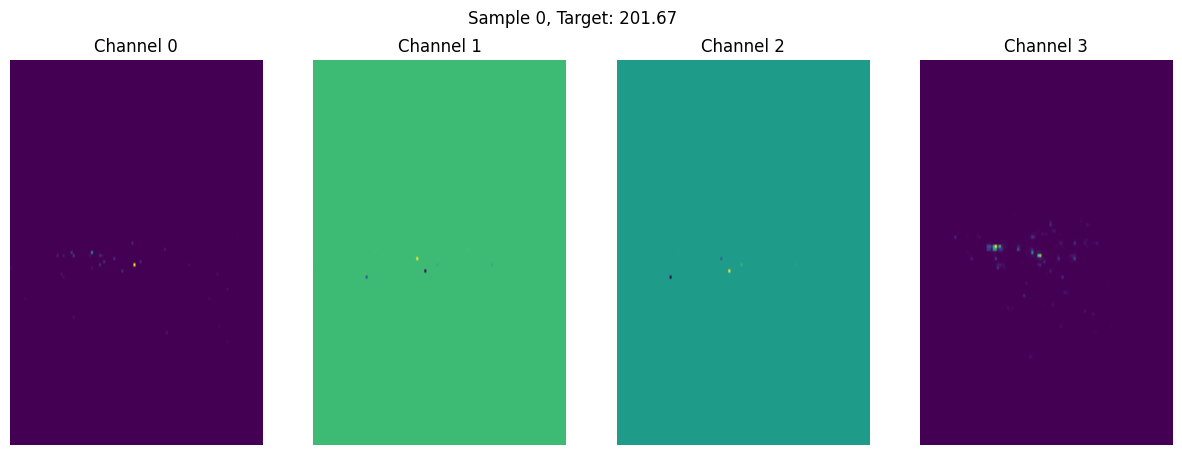

In [12]:
# Visualize sample data from the dataset
if dataset is not None and len(dataset) > 0:
    x, y = dataset[0]
    fig, axes = plt.subplots(1, x.shape[0], figsize=(15, 5))
    for i in range(x.shape[0]):
        axes[i].imshow(x[i], aspect='auto', cmap='viridis')
        axes[i].set_title(f'Channel {i}')
        axes[i].axis('off')
    plt.suptitle(f'Sample 0, Target: {y.item():.2f}')
    plt.show()